<div style="
    border-radius: 15px;
    overflow: hidden;
    position: relative;
    border: 2px solid #003366;
">
    <div style="
        background-image: url('https://iili.io/CKv7LCB.jpg');
        background-size: cover;
        background-position: center;
        padding: 40px 20px;
        position: relative;
    ">
        <!-- Overlay -->
        <div style="
            position: absolute;
            inset: 0;
            background: rgba(0,0,0,0.45);
        "></div>
        <!-- Content -->
        <h1 style="
            position: relative;
            z-index: 1;
            color: white;
            text-align: center;
            font-size: 38px;
            font-weight: bold;
            text-shadow: 2px 2px 8px rgba(0,0,0,0.9);
            margin: 0;
        ">
            🌌 Classifying Stars, Galaxies & Quasars 🔭
        </h1>
    </div>
</div>

# 📂 Overview
In astronomy, the classification of celestial objects into stars, galaxies, and quasars based on their spectral and photometric characteristics is one of the most fundamental tasks in the field. The early cataloguing of stars and their distribution across the sky led to the realization that they form our own galaxy. Later, the recognition that Andromeda was a separate galaxy sparked the systematic survey of countless galaxies as more powerful telescopes were developed.

**Celestial Objects**

These are the three classes we are trying to classify this competition :

**Stars**  
<img src="https://iili.io/CKvPBUB.jpg" width="200">

Stars are massive, luminous spheres of plasma held together by gravity. They generate energy through nuclear fusion in their cores (mainly converting hydrogen into helium).

**Galaxies**  

<img src="https://iili.io/CKvPnHP.jpg" width="200">

Galaxies are enormous systems containing billions to trillions of stars, gas, dust, and dark matter, all bound together by gravity.


**Quasars**  

<img src="https://iili.io/CKvP3Vj.jpg" width="200">

Quasars are the most luminous objects in the universe. They are powered by supermassive black holes at the centers of distant galaxies that are actively accreting (pulling in) huge amounts of gas and dust.

**Key Features**

| #  | Feature              | Description |
|----|----------------------|-------------|
| 1  | **id**               | Row identifier (unique index for each object in the synthetic dataset). |
| 2  | **alpha**            | Right Ascension angle (at J2000 epoch). |
| 3  | **delta**            | Declination angle (at J2000 epoch). |
| 4  | **u**                | Ultraviolet filter in the photometric system. |
| 5  | **g**                | Green filter in the photometric system. |
| 6  | **r**                | Red filter in the photometric system. |
| 7  | **i**                | Near Infrared filter in the photometric system. |
| 8  | **z**                | Infrared filter in the photometric system. |
| 9  | **redshift**         | Redshift value based on the increase in wavelength. |
| 10 | **spectral_type**    | Derived stellar spectral type based on `r - g` color index.<br>Possible values: **M**, **G/K**, **A/F**, **O/B**. |
| 11 | **galaxy_population** | Derived galaxy population type based on `u - r` color index.<br>Possible values: **Blue_Cloud**, **Red_Sequence**. |
| 12 | **class**            | Object class (target variable) — identifies whether the object is a **GALAXY**, **STAR**, or **QSO** (quasar). |

**Files Provided**

From *Kaggle Playground Series – Season 6, Episode 6*:

* `train.csv`: Training dataset with target.
* `test.csv`: Test dataset without target.
* `sample_submission.csv`: Submission template.

(Source: [Kaggle Competition – S6E6](https://www.kaggle.com/competitions/playground-series-s6e6))

From *Kaggle Dataset – Irrigation Water Requirement Prediction*:

* `star_classification.csv`: Main dataset containing all features and target variable
* The dataset is publicly available on Kaggle and designed for predicting Stellar Class

(Source:
[Stellar Classification Dataset - SDSS17](https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17/data))

**Notebook Overview**
In this notebook, we will go through the following steps:

- **Data Exploration**: Understand the data, check data quality, and perform both statistical and astronomy-specific EDA.
- **Feature Engineering**: Create new features using the original SDSS17 dataset and various encoding techniques.
- **Modeling**: Train a CatBoost model using Stratified K-Fold cross-validation.
- **Evaluation**: Analyze model performance using Balanced Accuracy, Confusion Matrix, and Feature Importance.
- **Submission**: Final prediction.

<!-- Google Font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px;
    overflow: hidden;
    border: 2px solid #003366;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.5);
">
    <div style="
        background-image: url('https://iili.io/CKv7LCB.jpg');
        background-size: cover;
        background-position: center;
        padding: 30px 20px;
        position: relative;
    ">
        <!-- Dark Overlay -->
        <div style="
            position: absolute;
            inset: 0;
            background: rgba(0,0,0,0.45);
        "></div>
        <!-- Title -->
        <h1 style="
            position: relative;
            z-index: 1;
            color: #FFFFFF;
            text-shadow: 2px 2px 6px rgba(0,0,0,0.9);
            font-weight: bold;
            margin: 0;
            font-size: 32px;
            font-family: 'Roboto', sans-serif;
            letter-spacing: 1px;
            text-align: center;
        ">
            📚 Import Libraries
        </h1>
    </div>
</div>


In [24]:
# =====================================================
# Standard Library
# =====================================================
import gc
import logging
import os
import sys
import warnings
from itertools import combinations
from logging.handlers import RotatingFileHandler
from typing import Iterable, List, Optional

# =====================================================
# Third-party Libraries
# =====================================================
import numpy as np
import optuna
import pandas as pd
import pingouin as pg
import scikit_posthocs as sp
import seaborn as sns
import xgboost as xgb
from colorlog import ColoredFormatter
from IPython.display import HTML, display
from scipy.optimize import minimize
from scipy.stats import (
    chi2_contingency,
    kurtosis,
    kruskal,
    levene,
    mannwhitneyu,
    probplot,
    skew,
    ttest_ind,
)
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, TargetEncoder
from sklearn.utils.class_weight import compute_sample_weight
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from tqdm import tqdm

# =====================================================
# Visualization
# =====================================================
import matplotlib.pyplot as plt

# =====================================================
# Configuration
# =====================================================
warnings.filterwarnings("ignore")

optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_colwidth", None)

In [25]:
class CFG:
    """Global config for experiment, data paths, and utilities."""

    # ===== Experiment settings =====
    RANDOM_STATE = 42
    N_SPLIT_KFOLD = 5
    THRESHOLD = 0.5
    PSEUDO_THRESH = 0.92

    # ===== Target / ID =====
    TARGET_FEATURE = "class"
    ID_COLUMN = "id"
    OBJ_ID_COLUMN = "obj_ID"

    # ===== Data paths =====
    ORIGINAL_DATA = "star_classification.csv"
    TRAIN_DATA = "train.csv"
    TEST_DATA = "test.csv"

    # ===== Label mapping =====
    TARGET_MAPPING = {"GALAXY": 0, "QSO": 1, "STAR": 2}
    INV_TARGET_MAPPING = {0: "GALAXY", 1: "QSO", 2: "STAR"}

    # ===== Plot colors =====
    COLORS = ["#667eea", "#764ba2", "#a855f7", "#f093fb", "#fbc2eb"]

    # =====================================================
    # Logger
    # =====================================================
    @staticmethod
    def setup_notebook_logger(level: int = logging.DEBUG) -> logging.Logger:
        """Create clean logger (no duplicate handlers, colored console)."""
        logger = logging.getLogger("nb")
        logger.setLevel(level)
        logger.propagate = False  # avoid duplicate logs

        if logger.hasHandlers():
            logger.handlers.clear()  # reset handlers

        # colored console formatter
        color_formatter = ColoredFormatter(
            "%(log_color)s%(asctime)s | %(levelname)-8s | %(message)s",
            datefmt="%Y-%m-%d %H:%M:%S",
            log_colors={
                "DEBUG": "white",
                "INFO": "green",
                "WARNING": "yellow",
                "ERROR": "red",
                "CRITICAL": "bold_red",
            },
        )

        console_handler = logging.StreamHandler(sys.stdout)
        console_handler.setFormatter(color_formatter)
        logger.addHandler(console_handler)

        logger.info(f"Logging configured: level={logging.getLevelName(level)}")
        return logger

    # =====================================================
    # Data Utils
    # =====================================================
    @staticmethod
    def read_csv_safe(
        path: str,
        logger: logging.Logger,
        encodings: Iterable[str] = ("utf-8", "latin1", "cp1252", "ISO-8859-1"),
    ) -> Optional[pd.DataFrame]:
        """Read CSV with fallback encodings."""
        if not os.path.exists(path):
            logger.error(f"File not found: {path}")
            return None

        for enc in encodings:
            try:
                df = pd.read_csv(path, encoding=enc)
                logger.info(f"Loaded: {enc} | Shape: {df.shape}")
                return df
            except UnicodeDecodeError:
                logger.warning(f"Failed encoding: {enc}")
            except pd.errors.EmptyDataError:
                logger.error("Empty CSV.")
                return None
            except pd.errors.ParserError:
                logger.error("Parse error.")
                return None
            except Exception as e:
                logger.error(f"Unexpected error: {e}")
                return None

        logger.error("All encodings failed.")
        return None

    @staticmethod
    def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
        """Standardize column names."""
        df.columns = (
            df.columns.str.strip()
            .str.replace(r"[^\w\s]", "", regex=True)
            .str.replace(r"\s+", "_", regex=True)
        )
        return df

    @staticmethod
    def reduce_mem_usage(cols: List[str], df: pd.DataFrame) -> pd.DataFrame:
        """Downcast numeric types to reduce memory."""
        for col in cols:
            col_type = df[col].dtype
            if pd.api.types.is_numeric_dtype(col_type):
                c_min, c_max = df[col].min(), df[col].max()
                if pd.api.types.is_integer_dtype(col_type):
                    if np.iinfo(np.int8).min < c_min < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif np.iinfo(np.int16).min < c_min < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                else:
                    if np.finfo(np.float32).min < c_min < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype("category")  # convert object → category
        return df

    @staticmethod
    def convert_cat(features: List[str], df: pd.DataFrame) -> pd.DataFrame:
        """Convert selected columns to category dtype."""
        for feature in features:
            if feature in df.columns:
                df[feature] = df[feature].astype("category")
        return df

<!-- Google Font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px;
    overflow: hidden;
    border: 2px solid #003366;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.5);
">
    <div style="
        background-image: url('https://iili.io/CKv7LCB.jpg');
        background-size: cover;
        background-position: center;
        padding: 30px 20px;
        position: relative;
    ">
        <!-- Dark Overlay -->
        <div style="
            position: absolute;
            inset: 0;
            background: rgba(0,0,0,0.45);
        "></div>
        <!-- Title -->
        <h1 style="
            position: relative;
            z-index: 1;
            color: #FFFFFF;
            text-shadow: 2px 2px 6px rgba(0,0,0,0.9);
            font-weight: bold;
            margin: 0;
            font-size: 32px;
            font-family: 'Roboto', sans-serif;
            letter-spacing: 1px;
            text-align: center;
        ">
            Load Data
        </h1>
    </div>
</div>


In [26]:
# Initialize notebook logger
logger = CFG.setup_notebook_logger()

# Load datasets safely
df_train = CFG.read_csv_safe(CFG.TRAIN_DATA, logger).pipe(CFG.clean_columns)
df_test = CFG.read_csv_safe(CFG.TEST_DATA, logger).pipe(CFG.clean_columns)
df_original = CFG.read_csv_safe(CFG.ORIGINAL_DATA, logger).pipe(CFG.clean_columns)

2026-06-04 20:45:31 | INFO     | Logging configured: level=DEBUG
2026-06-04 20:45:32 | INFO     | Loaded: utf-8 | Shape: (577347, 12)
2026-06-04 20:45:32 | INFO     | Loaded: utf-8 | Shape: (247435, 11)
2026-06-04 20:45:33 | INFO     | Loaded: utf-8 | Shape: (100000, 18)


<!-- Google Font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px;
    overflow: hidden;
    border: 2px solid #003366;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.5);
">
    <div style="
        background-image: url('https://iili.io/CKv7LCB.jpg');
        background-size: cover;
        background-position: center;
        padding: 30px 20px;
        position: relative;
    ">
        <!-- Dark Overlay -->
        <div style="
            position: absolute;
            inset: 0;
            background: rgba(0,0,0,0.45);
        "></div>
        <!-- Title -->
        <h1 style="
            position: relative;
            z-index: 1;
            color: #FFFFFF;
            text-shadow: 2px 2px 6px rgba(0,0,0,0.9);
            font-weight: bold;
            margin: 0;
            font-size: 32px;
            font-family: 'Roboto', sans-serif;
            letter-spacing: 1px;
            text-align: center;
        ">
            Data Preview and Info
        </h1>
    </div>
</div>


In [27]:
datasets = {"Train": df_train, "Test": df_test, "Original": df_original}

for name, df in datasets.items():
    logger.info(f"{name} Data Preview")
    display(df.head())

# Display information about the DataFrames
for name, df in datasets.items():
    logger.info(f"{name} Data Info")
    df.info()

2026-06-04 20:45:33 | INFO     | Train Data Preview


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


2026-06-04 20:45:33 | INFO     | Test Data Preview


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


2026-06-04 20:45:33 | INFO     | Original Data Preview


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


2026-06-04 20:45:33 | INFO     | Train Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB
2026-06-04 20:45:33 | INFO     | Test Data Info
<class 'pandas.core.frame.DataFrame'>
Range

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<h2 style="color:#f9e79f; margin-top:0;">
    🌌 Insights from Initial Data Exploration
</h2>

<h3>Dataset Size and Structure</h3>
<ul>
  <li><b>Training dataset</b>: 577,347 samples, 12 columns (including <code>class</code> target variable).</li>
  <li><b>Test dataset</b>: 247,435 samples, 11 columns (excluding <code>class</code>).</li>
  <li><b>Original dataset</b>: 100,000 samples, 18 columns.</li>
  <li>Train and test datasets share nearly identical feature structures except for the target column.</li>
  <li>The original SDSS dataset contains additional astronomical observation metadata such as 
      <code>run_ID</code>, <code>cam_col</code>, <code>field_ID</code>, and <code>fiber_ID</code>.
  </li>
  <li>Large-scale synthetic datasets provide strong diversity for robust stellar classification modeling.</li>
</ul>

<h3>Feature Overview</h3>
<ul>
  <li>Dataset contains <b>astronomical positional data, photometric filters, spectral information, and redshift measurements</b>.</li>

  <li><b>Numerical features (9):</b>
      <code>id</code>, <code>alpha</code>, <code>delta</code>,
      <code>u</code>, <code>g</code>, <code>r</code>,
      <code>i</code>, <code>z</code>, <code>redshift</code>.
  </li>

  <li><b>Categorical features (3):</b>
      <code>spectral_type</code>, <code>galaxy_population</code>, <code>class</code>.
  </li>

  <li><code>class</code> is a <b>multi-class target variable</b> representing:
      <b>GALAXY</b>, <b>STAR</b>, and <b>QSO (quasar)</b>.
  </li>

  <li>Photometric filters (<code>u, g, r, i, z</code>) capture light intensity across different wavelength bands.</li>

  <li><code>redshift</code> is expected to be one of the most informative astrophysical features for distinguishing celestial objects.</li>
</ul>

<h3>Data Completeness and Types</h3>
<ul>
  <li>No missing values detected across train, test, and original datasets.</li>
  <li>Feature data types are clean and consistent without obvious mismatch issues.</li>
  <li>Categorical variables stored as <code>object</code> require encoding before machine learning modeling.</li>
  <li>No obvious duplicated columns or direct data leakage features identified.</li>
  <li>The <code>id</code> column appears to be a unique identifier and may provide limited predictive value.</li>
</ul>

<h3>Memory and Efficiency</h3>
<ul>
  <li>Training dataset memory usage: ~52.9 MB.</li>
  <li>Test dataset memory usage: ~20.8 MB.</li>
  <li>Original dataset memory usage: ~13.7 MB.</li>
  <li>Memory consumption is relatively efficient despite the large dataset size.</li>
  <li>Converting string-based categorical features to <code>category</code> dtype can further reduce memory usage and improve training performance.</li>
</ul>

</div>

In [28]:
num_features = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift"]
cat_features = ["spectral_type", "galaxy_population"]

# Drop columns id
df_train.drop(columns=CFG.ID_COLUMN, inplace=True)
list_test_id = df_test[CFG.ID_COLUMN].copy().to_list()
df_test.drop(columns=CFG.ID_COLUMN, inplace=True)
df_original.drop(columns=CFG.OBJ_ID_COLUMN, inplace=True)

# Reduce memory and convert to category
df_train = CFG.reduce_mem_usage(cols=num_features, df=df_train)
df_test = CFG.reduce_mem_usage(cols=num_features, df=df_test)
df_original = CFG.reduce_mem_usage(cols=num_features, df=df_original)

df_train = CFG.convert_cat(features=cat_features, df=df_train)
df_test = CFG.convert_cat(features=cat_features, df=df_test)
df_original = CFG.convert_cat(features=cat_features, df=df_original)

# Display information about the DataFrames
for name, df in datasets.items():
    logger.info(f"{name} Data Info")
    df.info()

2026-06-04 20:45:33 | INFO     | Train Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   alpha              577347 non-null  float32 
 1   delta              577347 non-null  float32 
 2   u                  577347 non-null  float32 
 3   g                  577347 non-null  float32 
 4   r                  577347 non-null  float32 
 5   i                  577347 non-null  float32 
 6   z                  577347 non-null  float32 
 7   redshift           577347 non-null  float32 
 8   spectral_type      577347 non-null  category
 9   galaxy_population  577347 non-null  category
 10  class              577347 non-null  object  
dtypes: category(2), float32(8), object(1)
memory usage: 23.1+ MB
2026-06-04 20:45:33 | INFO     | Test Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247435 entries, 0 to 24743

## Numerical Feature Summary — Data Analyst Perspective

In [29]:
cm = sns.light_palette("blue", as_cmap=True)
for name, df in datasets.items():
    logger.info(f"{name} Data Describe:")
    display(df[num_features].describe().T.style.background_gradient(cmap=cm))

2026-06-04 20:45:33 | INFO     | Train Data Describe:


,count,mean,std,min,25%,50%,75%,max
alpha,577347.000000,181.616653,96.242943,0.011684,132.161499,188.681473,231.829689,359.999817
delta,577347.000000,21.834658,18.933571,-17.966988,2.474097,21.484411,36.988310,79.158325
u,577347.000000,22.441927,2.018135,-0.139225,20.977090,22.570223,23.869102,28.253263
g,577347.000000,21.007273,1.795426,13.535483,19.865005,21.467819,22.292715,27.620207
r,577347.000000,19.962809,1.648964,12.579407,18.820670,20.431152,21.164096,25.254499
i,577347.000000,19.378908,1.580059,11.962782,18.306820,19.631641,20.608191,27.910852
z,577347.000000,19.041134,1.584365,11.682803,17.973192,19.188599,20.162112,26.826866
redshift,577347.000000,0.723135,0.810070,-0.009970,0.181052,0.497525,0.881390,7.010780


2026-06-04 20:45:33 | INFO     | Test Data Describe:


,count,mean,std,min,25%,50%,75%,max
alpha,247435.000000,181.360626,96.213379,0.010959,132.023949,188.559433,231.690063,359.999725
delta,247435.000000,21.853897,18.931366,-17.959259,2.527822,21.452023,37.061924,79.170433
u,247435.000000,22.442070,2.019044,13.902664,20.978208,22.569616,23.869689,27.835632
g,247435.000000,21.009834,1.798633,13.374549,19.866076,21.469175,22.294539,27.173410
r,247435.000000,19.965652,1.650949,10.390731,18.831804,20.431513,21.165467,25.291985
i,247435.000000,19.381863,1.581880,10.034181,18.314240,19.632235,20.618391,24.567823
z,247435.000000,19.043152,1.587103,10.632026,17.976477,19.196316,20.167749,25.700336
redshift,247435.000000,0.724781,0.810582,-0.009968,0.183117,0.498598,0.882659,7.007179


2026-06-04 20:45:33 | INFO     | Original Data Describe:


,count,mean,std,min,25%,50%,75%,max
alpha,100000.000000,177.629120,96.502243,0.005528,127.518223,180.900703,233.895004,359.999817
delta,100000.000000,24.135302,19.644665,-18.785328,5.146771,23.645923,39.901548,83.000519
u,100000.000000,21.980471,31.769291,-9999.000000,20.352352,22.179135,23.687440,32.781391
g,100000.000000,20.531385,31.750292,-9999.000000,18.965231,21.099834,22.123768,31.602240
r,100000.000000,19.645763,1.854760,9.822070,18.135828,20.125291,21.044785,29.571859
i,100000.000000,19.084854,1.757895,9.469903,17.732285,19.405145,20.396495,32.141472
z,100000.000000,18.668812,31.728151,-9999.000000,17.460677,19.004595,19.921120,29.383739
redshift,100000.000000,0.576661,0.730707,-0.009971,0.054517,0.424173,0.704154,7.011245


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 22px;
    border-radius: 12px;
    margin: 20px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<h2 style="color:#f9e79f; margin-top:0;">
    📊 Insights from Numerical Feature Summary
</h2>

<ul>
    <li>Train and test datasets show <b>very similar statistical distributions</b>, indicating a well-balanced synthetic data generation process.</li>
    <li><code>alpha</code> spans nearly the full celestial coordinate range 
        (<b>0° → 360°</b>), confirming broad sky coverage.</li>
    <li><code>delta</code> values include both negative and positive ranges, representing observations across different celestial hemispheres.</li>
    <li>Photometric filter features 
        (<code>u</code>, <code>g</code>, <code>r</code>, <code>i</code>, <code>z</code>) 
        exhibit relatively stable distributions with moderate variance.</li>
    <li><code>redshift</code> shows noticeable spread and positive skewness, suggesting the presence of distant astronomical objects such as quasars.</li>
    <li>The original SDSS dataset contains extreme placeholder values 
        (<code>-9999</code>) in several photometric columns, indicating missing or invalid astronomical observations.</li>
    <li>Original dataset distributions differ slightly from the synthetic train/test datasets, particularly in 
        <code>u</code>, <code>g</code>, and <code>z</code> bands.</li>
    <li>Data cleaning and handling invalid values will be important before integrating the original SDSS dataset into model training.</li>
</ul>

</div>

## Categorical Feature Summary — Data Analyst Perspective

In [32]:
def spectral_type(g, r):
    color = np.asarray(r) - np.asarray(g)
    conditions = [
        color < -1,
        (color >= -1) & (color < -0.5),
        (color >= -0.5) & (color < 0),
        color >= 0]
    choices = ["M", "G/K", "A/F", "O/B"]
    result = np.select(conditions, choices, default="Unknown")
    return pd.Series(result).astype(str)


def galaxy_population(u, r):
    color = np.asarray(u) - np.asarray(r)
    result = np.where(color < 2.2, "Blue_Cloud", "Red_Sequence")
    return pd.Series(result).astype(str)
    
df_original["spectral_type"] = spectral_type(df_original["g"], df_original["r"])
df_original["galaxy_population"] = galaxy_population(df_original["u"], df_original["r"])
df_original = df_original[df_train.columns]

for name, df in datasets.items():
    logger.info(f"{name} Data Describe:")
    display(df[cat_features].astype("category").describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

2026-06-04 21:14:24 | INFO     | Train Data Describe:


,count,unique,top,freq
spectral_type,577347,4,M,303323
galaxy_population,577347,2,Red_Sequence,319565


2026-06-04 21:14:25 | INFO     | Test Data Describe:


,count,unique,top,freq
spectral_type,247435,4,M,129852
galaxy_population,247435,2,Red_Sequence,136588


2026-06-04 21:14:25 | INFO     | Original Data Describe:


,count,unique,top,freq
spectral_type,100000,4,M,47148
galaxy_population,100000,2,Red_Sequence,52609


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 22px;
    border-radius: 12px;
    margin: 20px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<h2 style="color:#f9e79f; margin-top:0;">
    🌌 Insights from Categorical Features
</h2>

<ul>
    <li><code>spectral_type</code> contains <b>4 stellar categories</b>, with 
        <b>M-type</b> being the dominant spectral class across all datasets.</li>
    <li><code>galaxy_population</code> contains <b>2 galaxy groups</b>:
        <b>Red_Sequence</b> and <b>Blue_Cloud</b>.</li>
    <li><b>Red_Sequence</b> is the majority population in train, test, and original datasets, indicating a higher proportion of older and redder galaxies.</li>
    <li>Category distributions remain highly consistent between train and test datasets, suggesting stable synthetic data generation.</li>
    <li>The original SDSS dataset follows a similar categorical pattern, improving compatibility for potential dataset merging.</li>
    <li>No unexpected categorical levels or label inconsistencies were detected across datasets.</li>
</ul>

</div>

<!-- Google Font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px;
    overflow: hidden;
    border: 2px solid #003366;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.5);
">
    <div style="
        background-image: url('https://iili.io/CKv7LCB.jpg');
        background-size: cover;
        background-position: center;
        padding: 30px 20px;
        position: relative;
    ">
        <!-- Dark Overlay -->
        <div style="
            position: absolute;
            inset: 0;
            background: rgba(0,0,0,0.45);
        "></div>
        <!-- Title -->
        <h1 style="
            position: relative;
            z-index: 1;
            color: #FFFFFF;
            text-shadow: 2px 2px 6px rgba(0,0,0,0.9);
            font-weight: bold;
            margin: 0;
            font-size: 32px;
            font-family: 'Roboto', sans-serif;
            letter-spacing: 1px;
            text-align: center;
        ">
            Data Quality Check
        </h1>
    </div>
</div>


## Missing Value

In [33]:
def displayNULL(df: pd.DataFrame) -> None:
    """
    Display and log missing value statistics for a given dataset.

    This function checks for missing values (including blank strings),
    summarizes missing counts and percentages per feature, and reports
    the results using logging and formatted tables when available.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be inspected for missing values.

    Returns
    -------
    None
        Prints missing value summary and logs overall statistics.
    """

    # Get total number of rows
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    # Compute missing value statistics per column
    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]

    # Keep only columns with missing values
    missing_df = missing_df[missing_df["Missing_Count"] > 0]

    # Calculate missing percentage
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)

    # Sort by missing count (descending)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    # Calculate total missing value
    total_missing = missing_df["Missing_Count"].sum()

    # Log and display results
    if total_missing == 0:
        logger.info(f"No missing values detected in {total_rows:,} rows.")
    else:
        # Try to print nicely formatted table
        try:
            from tabulate import tabulate
            table_str = tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, 
                           colalign=("left", "left", "left"))
            logger.warning("\n" + table_str)
        except ImportError:
            logger.error(missing_df.to_string(index=False))

        logger.warning(f"Total missing values: {total_missing:,} out of {total_rows:,} rows.")

logger.info("Start checking NULL values")

for name, df in datasets.items():
    logger.info(f"Checking missing values for {name}...")
    displayNULL(df)
    logger.info("-" * 80)

logger.info("Completed checking for NULL values across datasets.")

2026-06-04 21:16:31 | INFO     | Start checking NULL values
2026-06-04 21:16:31 | INFO     | Checking missing values for Train...
2026-06-04 21:16:32 | INFO     | No missing values detected in 577,347 rows.
2026-06-04 21:16:32 | INFO     | --------------------------------------------------------------------------------
2026-06-04 21:16:32 | INFO     | Checking missing values for Test...
2026-06-04 21:16:32 | INFO     | No missing values detected in 247,435 rows.
2026-06-04 21:16:32 | INFO     | --------------------------------------------------------------------------------
2026-06-04 21:16:32 | INFO     | Checking missing values for Original...
2026-06-04 21:16:32 | INFO     | No missing values detected in 100,000 rows.
2026-06-04 21:16:32 | INFO     | --------------------------------------------------------------------------------
2026-06-04 21:16:32 | INFO     | Completed checking for NULL values across datasets.


## Checking duplicate Value

In [34]:
def check_duplicates_report(df: pd.DataFrame) -> None:
    """
    Check and log duplicate rows in a dataset.

    This function identifies fully duplicated rows in the input DataFrame
    and reports the results using the configured logger.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be checked for duplicate rows.

    Returns
    -------
    None
        Logs duplicate statistics to the console or log file.
    """

    duplicates_count = df.duplicated().sum()
    total_rows = len(df)

    if duplicates_count == 0:
        logger.info(f"No duplicate rows found out of {total_rows:,} total rows.")
    else:
        logger.warning(f"{duplicates_count:,} duplicate rows detected ({duplicates_count/total_rows:.2%}).")
        logger.warning(f"Rows affected: {duplicates_count:,} out of {total_rows:,}.")

logger.info("Start checking duplicate values")
duplicate_summary = {}

for name, data in datasets.items():
    logger.info(f"{name} duplicate Analysis...")
    check_duplicates_report(data)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }
    logger.info("-" * 80)

logger.info("Duplicate value inspection successfully completed across datasets.")

2026-06-04 21:16:45 | INFO     | Start checking duplicate values
2026-06-04 21:16:45 | INFO     | Train duplicate Analysis...
2026-06-04 21:16:45 | INFO     | No duplicate rows found out of 577,347 total rows.
2026-06-04 21:16:46 | INFO     | --------------------------------------------------------------------------------
2026-06-04 21:16:46 | INFO     | Test duplicate Analysis...
2026-06-04 21:16:46 | INFO     | No duplicate rows found out of 247,435 total rows.
2026-06-04 21:16:46 | INFO     | --------------------------------------------------------------------------------
2026-06-04 21:16:46 | INFO     | Original duplicate Analysis...
2026-06-04 21:16:46 | INFO     | No duplicate rows found out of 100,000 total rows.
2026-06-04 21:16:47 | INFO     | --------------------------------------------------------------------------------
2026-06-04 21:16:47 | INFO     | Duplicate value inspection successfully completed across datasets.


## Checking Outlier Value

In [35]:
def checking_outlier(df, dataset_name, list_feature = num_features, 
                     logger=logger) -> pd.DataFrame:
    """
    Detect and report outliers using the IQR (Interquartile Range) method.

    This function identifies outliers for specified numerical features
    based on the 1.5 × IQR rule, logs detailed statistics, and returns
    a summary table for reporting and monitoring purposes.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be inspected for outliers.

    dataset_name : str
        Name of the dataset (used for logging context).

    num_features : list
        List of numerical feature names to be checked.

    logger : logging.Logger, optional
        Logger instance for recording inspection results.

    Returns
    -------
    pandas.DataFrame
        Summary table containing:
        - feature (str): Feature name
        - outlier_count (int): Number of detected outliers
    """

    # Log inspection start
    logger.info(f"Checking outliers for {dataset_name}...")
    logger.info("-" * 80)

    outlier_info = []

    # Iterate through numerical features
    for feature in list_feature:
        # Compute quartiles
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        outlier_count = len(outliers)

        # Log results for each feature
        if outlier_count == 0:
            logger.debug(f"[{dataset_name}] {feature}: No outliers detected")
        else:
            logger.warning(
                f"[{dataset_name}] {feature}: {outlier_count:,} outliers detected "
                f"(lower={lower_bound:.3f}, upper={upper_bound:.3f})"
            )
            outlier_info.append({
                "Feature": feature,
                "Outlier_Count": outlier_count
            })

    # Log summary
    if not outlier_info:
        logger.info(f"[{dataset_name}] No outliers detected across all features.")
    else:
        logger.info(f"[{dataset_name}] Outliers detected in {len(outlier_info)} features.")

    logger.info("-" * 80)

    return pd.DataFrame(outlier_info)

logger.info("Start checking outlier across datasets")
duplicate_summary = {}
for name, data in datasets.items():
    outlier_data = checking_outlier(df=data, dataset_name=name)
    # display(outlier_data)

logger.info("Outlier checking successfully completed across datasets.")

2026-06-04 21:17:00 | INFO     | Start checking outlier across datasets
2026-06-04 21:17:00 | INFO     | Checking outliers for Train...
2026-06-04 21:17:00 | INFO     | --------------------------------------------------------------------------------
2026-06-04 21:17:00 | DEBUG    | [Train] alpha: No outliers detected
2026-06-04 21:17:00 | DEBUG    | [Train] delta: No outliers detected
2026-06-04 21:17:00 | WARNING  | [Train] u: 315 outliers detected (lower=16.639, upper=28.207)
2026-06-04 21:17:00 | WARNING  | [Train] g: 2,806 outliers detected (lower=16.223, upper=25.934)
2026-06-04 21:17:00 | WARNING  | [Train] r: 1,677 outliers detected (lower=15.306, upper=24.679)
2026-06-04 21:17:00 | WARNING  | [Train] i: 1,277 outliers detected (lower=14.855, upper=24.060)
2026-06-04 21:17:00 | WARNING  | [Train] z: 1,476 outliers detected (lower=14.690, upper=23.445)
2026-06-04 21:17:00 | WARNING  | [Train] redshift: 52,590 outliers detected (lower=-0.869, upper=1.932)
2026-06-04 21:17:00 | INF

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
🌌 Data Quality Insights: Missing Values, Duplicates, and Outliers
</div>

<h3 style="margin-top:10px;">Missing Values Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">
<li>Comprehensive missing value checks were performed across <b>Train</b>, <b>Test</b>, and <b>Original</b> datasets.</li>

<li><b>No missing values detected</b> in all datasets 
    (577K / 247K / 100K rows).</li>

<li>This indicates a highly complete dataset structure and removes the need for missing value imputation.</li>
</ul>

<h3>Duplicate Records Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">
<li>Duplicate inspections were conducted to ensure data integrity and avoid repeated astronomical observations.</li>

<li><b>No duplicate rows found</b> across Train, Test, and Original datasets.</li>

<li>Each record appears to represent a unique celestial object observation.</li>
</ul>

<h3>Outlier Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">
<li>Outlier detection was applied to all numerical astronomical features using the IQR method.</li>

<li><code>alpha</code> and <code>delta</code> showed stable distributions with <b>no detectable outliers</b>.</li>

<li>Photometric filter features 
    (<code>u</code>, <code>g</code>, <code>r</code>, <code>i</code>, <code>z</code>) 
    contain a relatively small number of outliers compared to the overall dataset size.</li>

<li><code>redshift</code> contains the highest number of outliers across all datasets, likely representing distant galaxies or quasars with extreme cosmological shifts.</li>

<li>Train and test datasets exhibit highly consistent outlier patterns, suggesting stable synthetic data generation.</li>

<li>The original SDSS dataset shows fewer outliers overall but slightly different distribution boundaries compared to the synthetic datasets.</li>
</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Conclusion:</b> The datasets demonstrate <b>strong overall data quality</b> with no missing values and no duplicate records. 
Most detected outliers appear to be <b>scientifically meaningful astronomical observations</b> rather than data errors, especially in the <code>redshift</code> feature. Therefore, aggressive outlier removal may not be appropriate for this astrophysical classification task.
</div>

</div>

<!-- Google Font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px;
    overflow: hidden;
    border: 2px solid #003366;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.5);
">
    <div style="
        background-image: url('https://iili.io/CKv7LCB.jpg');
        background-size: cover;
        background-position: center;
        padding: 30px 20px;
        position: relative;
    ">
        <!-- Dark Overlay -->
        <div style="
            position: absolute;
            inset: 0;
            background: rgba(0,0,0,0.45);
        "></div>
        <!-- Title -->
        <h1 style="
            position: relative;
            z-index: 1;
            color: #FFFFFF;
            text-shadow: 2px 2px 6px rgba(0,0,0,0.9);
            font-weight: bold;
            margin: 0;
            font-size: 32px;
            font-family: 'Roboto', sans-serif;
            letter-spacing: 1px;
            text-align: center;
        ">
            Exploratory Data Analysis
        </h1>
    </div>
</div>


In [36]:
def color(n_colors: int=2, tone: str ="diverging"):
    """
    Generate a list of colors based on predefined Seaborn palettes or custom palettes.

    Parameters
    ----------
    n_colors : int, default=2
        Number of colors to generate. If the palette is continuous (e.g., diverging, viridis),
        colors are sampled evenly across the colormap. If the palette is categorical,
        the first `n_colors` colors are returned.

    tone : str, default="diverging"
        The color style or palette to use. Supported values include:
        - "diverging": Seaborn diverging palette (continuous)
        - "pastel": Pastel palette
        - "muted": Muted palette
        - "husl": HUSL palette
        - "Dark2": Dark2 palette
        - "viridis": Viridis palette
        - "crest": Crest palette
        - "Paired": Paired categorical palette
        - "rocket", "rocket_r": Rocket palette and its reversed version
        - "mako": Mako palette
        - "RdYlGn": Red–Yellow–Green palette
        - "modern": Custom modern-style color set
        - "custom": Custom pastel/bright mixed color set

    Returns
    -------
    list of tuple
        A list of RGB color tuples in the range [0, 1].

    Notes
    -----
    - For continuous palettes (e.g., diverging, viridis, rocket), colors are sampled
      evenly across the palette using `numpy.linspace`.
    - For categorical palettes, the function simply slices the first `n_colors` items.

    Examples
    --------
    >>> color(3, tone="pastel")
    [(...RGB...), (...), (...)]

    >>> color(5, tone="diverging")
    [(0...., 0...., 0....), ...]

    >>> color(4, tone="modern")
    [(0.902, 0.223, 0.275), ...]
    """
    if tone == "diverging":
        cmap = sns.diverging_palette(0, 230, as_cmap=True)
    elif tone == "pastel":
        cmap = sns.color_palette("pastel")
    elif tone == "muted":
        cmap = sns.color_palette("muted")
    elif tone == "husl":
        cmap = sns.color_palette("husl")
    elif tone == "Dark2":
        cmap = sns.color_palette("Dark2")
    elif tone == "viridis":
        cmap = sns.color_palette("viridis")
    elif tone == "crest":
        cmap = sns.color_palette("crest")
    elif tone == "Paired":
        cmap = sns.color_palette("Paired")
    elif tone == "rocket":
        cmap = sns.color_palette("rocket")
    elif tone == "rocket_r":
        cmap = sns.color_palette("rocket_r")
    elif tone == "mako":
        cmap = sns.color_palette("mako")
    elif tone == "RdYlGn":
        cmap = sns.color_palette("RdYlGn")
    elif tone == "modern":
        cmap = sns.color_palette(["#E63946","#F1FAEE","#A8DADC","#457B9D","#1D3557"])
    elif tone == "custom":
        cmap = sns.color_palette(["#A077FF","#D6BBFF","#FFCAF8","#FE86C1","#40CBEA", "#9CE8EE"])

    positions = np.linspace(0, 1, n_colors)
    return [cmap(p) for p in positions] if callable(cmap) else cmap[:n_colors]

def cal_ChiSquare(cat_feature: str, target_feature: str, df: pd.DataFrame,
                  show_expected: bool=False, show_residuals: bool=False, logger: logging.Logger=logger) -> None:
    """
    Perform a Chi-Square test of independence to evaluate whether two categorical variables
    are statistically associated (i.e., dependent) or independent from each other.

    This function tests the null hypothesis that the two categorical variables are independent.
    It prints the test statistic, degrees of freedom, p-value, and an interpretation based on the p-value.
    Optionally, it displays the expected frequency table under independence, and standardized residuals
    (including a heatmap) which help to identify specific group-level deviations.

    Parameters
    ----------
    cat_feature : str
        Name of the first categorical variable (typically the feature).

    target_feature : str
        Name of the second categorical variable (typically the target label).

    df : pd.DataFrame
        The input DataFrame containing the data.

    show_expected : bool, default=False
        If True, prints the expected frequencies under the assumption of independence.

    show_residuals : bool, default=False
        If True, prints the standardized residuals and shows them as a heatmap
        to identify where the strongest associations/deviations occur.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the Chi-Square test result, including statistical significance interpretation.
        Optionally prints expected values and standardized residuals.

    Notes
    -----
    - Hypotheses:
        H₀ (Null):     The two variables are independent (no association).
        H₁ (Alt.):      There is a dependency or association between the variables.

    - Interpretation:
        If p-value < 0.05 → Reject H₀ → Conclude that the variables are significantly associated.
        If p-value ≥ 0.05 → Fail to reject H₀ → No statistically significant association found.

    - Standardized residuals:
        - Values > +2 or < -2 indicate strong deviation from expected frequency (local dependency).
        - Useful for identifying specific group-level contributions to the overall Chi-Square result.

    References
    ----------
    - https://en.wikipedia.org/wiki/Chi-squared_test
    - https://www.scribbr.com/statistics/chi-square-test-of-independence/
    """
    logger.info(f"Chi-Square Test of Independence: '{cat_feature}' vs. '{target_feature}'...")

    # Contingency table
    crosstab = pd.crosstab(df[cat_feature], df[target_feature])
    chi2, p, dof, expected = chi2_contingency(crosstab)

    logger.info(f"Chi-squared statistic: {chi2:.3f}")
    logger.info(f"Degrees of freedom: {dof}")
    logger.info(f"p-value: {p:.6f}")

    if p < 0.05:
        logger.info("Result: p-value < 0.05 → Reject H₀")
        logger.info(f"Variables '{cat_feature}' and '{target_feature}' are statistically associated.")
    else:
        logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
        logger.warning(f"No statistically significant association detected between '{cat_feature}' and '{target_feature}'.")

    # Optional: show expected frequencies
    if show_expected:
        logger.debug("Expected frequencies under independence assumption:")
        print(pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns))

    # Optional: show standardized residuals
    if show_residuals:
        residuals = (crosstab - expected) / np.sqrt(expected)
        logger.debug("Displaying standardized residuals heatmap.")
        # Heatmap of residuals
        plt.figure(figsize=(10, 7))
        sns.heatmap(residuals, annot=True, cmap=sns.diverging_palette(0, 230, 90, 60, as_cmap=True), center=0, fmt=".2f", linewidths=0.5)
        plt.title(f"Standardized Residuals Heatmap: {cat_feature} vs {target_feature}", weight="bold", fontsize=12, pad=15)
        plt.ylabel(cat_feature)
        plt.xlabel("")
        plt.tight_layout()
        plt.show()

def perform_kruskal_test(df: pd.DataFrame, categorical_feature: str,
                         numeric_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform the Kruskal-Wallis H-test to determine whether there are statistically
    significant differences in the distribution of a numeric variable across
    three or more independent groups.

    If the result is significant (p < 0.05), Dunn's post-hoc test with Bonferroni correction
    is performed to identify which group pairs differ.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the categorical and numerical variables.

    categorical_feature : str
        The name of the categorical feature that defines the groups.

    numeric_feature : str
        The name of the numeric feature to be compared across groups.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the Kruskal-Wallis H-statistic, p-value, interpretation, and
        optionally the results of Dunn's post-hoc test.

    Notes
    -----
    - H₀ (null hypothesis): The distribution of the numeric variable is the same across all groups.
    - H₁ (alternative hypothesis): At least one group has a different distribution.
    - If p < 0.05 → reject H₀ → use Dunn’s test to explore specific group differences.
    - Kruskal-Wallis is a non-parametric alternative to one-way ANOVA.
    - It does not assume normality, but assumes:
        1. Independent samples
        2. Ordinal or continuous response variable
        3. Similar shapes of distributions

    Requirements
    ------------
    - `scipy.stats.kruskal`
    - `scikit-posthocs` package for Dunn’s test (`import scikit_posthocs as sp`)

    References
    ----------
    - https://www.geeksforgeeks.org/kruskal-wallis-test/
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html
    - https://scikit-posthocs.readthedocs.io/en/latest/index.html
    """

    # Extract values
    groups = df[categorical_feature].dropna().unique()
    if len(groups) < 3:
        logger.error(f"Error: Kruskal-Wallis H-test requires 3 or more groups.")
        return
    else:
        logger.info(f"Kruskal-Wallis Test: {numeric_feature} ~ {categorical_feature}...")
        logger.debug(f"Number of groups detected: {len(groups)}")
        data_groups = [df[df[categorical_feature] == g][numeric_feature].dropna() for g in groups]

        # Perform kruskal
        stat, p = kruskal(*data_groups)

        logger.info(f"Kruskal-Wallis H-statistic: {stat:.3f}")
        logger.info(f"p-value: {p}")

        if p < 0.05:
            logger.info("Significant difference detected among groups (p < 0.05).")
            logger.debug("Running Dunn's Post-Hoc Test (Bonferroni corrected)...")
            dunn_result = sp.posthoc_dunn(df, val_col=numeric_feature, group_col=categorical_feature, p_adjust="bonferroni")
            print(dunn_result)
        else:
            logger.warning("No statistically significant difference detected between groups (p ≥ 0.05).")

def check_normality_with_plots(df: pd.DataFrame, feature: str, target_feature: str, threshold_skew_1: float=0.5, threshold_skew_2: float=1.0,
                               threshold_kurt: float=1.5, ncols: int=2, logger: logging.Logger=logger) -> bool:
    """
    Assess the normality of a numerical feature across groups of a categorical variable
    using skewness, kurtosis, and Q–Q plot visualization.

    This function evaluates whether the distribution of a specified numerical feature
    follows an approximately normal distribution within each category of a target
    grouping variable. The assessment is based on:

    - Skewness (symmetry of the distribution)
    - Kurtosis (tailedness of the distribution)
    - Visual inspection using Q–Q plots

    If at least one group violates the normality assumption, the function flags
    non-normality and recommends the use of non-parametric statistical tests
    (e.g., Kruskal–Wallis, Mann–Whitney U).

    The function also produces:
    - Group-wise summary statistics (skewness, kurtosis, remarks)
    - Q–Q plots for visual assessment
    - A styled results table for reporting

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset containing both numerical and categorical variables.

    feature : str
        Name of the numerical feature to be tested for normality.

    target_feature : str
        Name of the categorical variable used to define comparison groups.

    threshold_skew_1 : float, default=0.5
        Threshold for approximate symmetry (|skewness| ≤ threshold_skew_1).

    threshold_skew_2 : float, default=1.0
        Threshold for moderate skewness
        (threshold_skew_1 < |skewness| ≤ threshold_skew_2).

    threshold_kurt : float, default=1.5
        Absolute kurtosis threshold for approximate normality.

    ncols : int, default=2
        Number of Q–Q plots displayed per row.

    logger : logging.Logger, optional
        Logger instance used for tracking analysis steps, statistical results,
        and recommendations.

    Returns
    -------
    bool
        True if at least one group violates the normality assumption.
        False if all groups are approximately normally distributed.

    Notes
    -----
    - This function is intended for exploratory data analysis and
      assumption checking prior to statistical hypothesis testing.
    - For small sample sizes, normality assessment should be interpreted
      with caution.
    - When non-normality is detected, non-parametric tests are preferred.

    Examples
    --------
    >>> check_normality_with_plots(
    ...     df=data,
    ...     feature="st_depression",
    ...     target_feature="heart_disease"
    ... )
    """

    results = []
    non_normal_detected = False

    logger.info(f"Checking normality of feature '{feature}' by groups of '{target_feature}'...")

    # ===== Group evaluation =====
    logger.info("Evaluating distribution characteristics (skewness & kurtosis)...")

    groups = df[target_feature].dropna().unique()
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.debug(f"Thresholds → |skew|≤{threshold_skew_1}, |kurtosis|≤{threshold_kurt}")

    for grp, subset in df.groupby(target_feature):
        data = subset[feature].dropna()
        sk = skew(data)
        kt = kurtosis(data)
        abs_sk = abs(sk)
        abs_kt = abs(kt)

        # Skewness interpretation
        if abs_sk <= threshold_skew_1:
            skew_remark = "Approximately symmetric"
        elif abs_sk <= threshold_skew_2:
            skew_remark = "Moderately skewed"
        else:
            skew_remark = "Highly skewed"

        # Kurtosis interpretation
        if abs_kt < threshold_kurt:
            kurt_remark = "Normal tails"
        else:
            kurt_remark = "Heavy/light tails"

        remark = f"{skew_remark}, {kurt_remark}"
        results.append({
            "Feature": feature,
            "Group": grp,
            "Skewness": f"{sk:.4f}",
            "Kurtosis": f"{kt:.4f}",
            "Remark": remark
        })

        logger.debug(f"[{target_feature}={grp}] skew={sk:.4f}, kurtosis={kt:.4f} → {remark}")

        # Flag if any group is not approximately normal
        if not (abs_sk <= threshold_skew_1 and abs_kt <= threshold_kurt):
            non_normal_detected = True

    # === Visual Q–Q plots ===
    logger.info("Generating Q–Q plots for visual assessment...")

    n_groups = df[target_feature].nunique()
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, grp in enumerate(df[target_feature].unique()):
        ax = axes[i]
        data = df.loc[df[target_feature] == grp, feature].dropna()
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{feature} — {grp}", fontsize=12, weight="bold", pad=15)
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Q–Q Plots of {feature} by {target_feature}", fontsize=12, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # === Display results table ===
    df_result = pd.DataFrame(results)
    cm = sns.light_palette("green", as_cmap=True)
    styled = (
        df_result.style
        .background_gradient(subset=["Skewness"], cmap=cm, vmin=-1, vmax=1)
        .background_gradient(subset=["Kurtosis"], cmap=cm, vmin=-1.5, vmax=1.5)
        .set_caption(
            f'<b><span style="font-size:14px; text-align:center; display:block;">'
            f'Skewness & Kurtosis of {feature} by {target_feature}'
            f'</span></b>'
        )
        .set_table_attributes('style="width:80%; margin:auto;"')
    )
    display(styled)

    # === Final evaluation ===
    if non_normal_detected:
        logger.warning("Normality assumption violated in at least one group.")
        logger.info("Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).")
    else:
        logger.info("All groups approximately follow a normal distribution.")

    return non_normal_detected

def perform_anova_with_tukey(df: pd.DataFrame, numeric_feature: str, categorical_feature: str, 
                             typ: int=2, logger: logging.Logger=logger) -> None:
    """
    Perform a One-Way ANOVA test to determine whether there are statistically
    significant differences between the means of three or more independent groups.

    If the ANOVA test is significant (p < 0.05), Tukey's HSD post-hoc test is performed
    to identify which specific pairs of groups differ from each other.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the numeric and categorical features.

    numeric_feature : str
        The name of the numerical (continuous) response variable.

    categorical_feature : str
        The name of the categorical (independent) variable used to group the data.

    typ : int, optional (default=2)
        The type of sum of squares to use in the ANOVA test:
        - Type I (1): Sequential.
        - Type II (2): Default and commonly used for balanced designs.
        - Type III (3): Use when model includes interaction terms or unbalanced data.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the ANOVA table, p-value, interpretation, and (if significant) the Tukey HSD test summary.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean is different.
    - If p < 0.05 → reject H₀ → perform Tukey’s HSD to find which groups differ.
    - Assumptions:
        1. Independence of observations
        2. Normally distributed groups (Shapiro or Anderson test can check this)
        3. Homogeneity of variances (Levene's test)

    References
    ----------
    - https://www.scribbr.com/statistics/one-way-anova/
    - https://en.wikipedia.org/wiki/Analysis_of_variance
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html
    """

    # Extract unique groups
    groups = df[categorical_feature].dropna().unique()

    if len(groups) < 3:
        logger.error("Error: ANOVA requires at least 3 groups.")
        return
    else:
        logger.info(f"Running ANOVA Test: {numeric_feature} ~ {categorical_feature} (Type {typ})...")
        logger.debug(f"Number of groups detected: {len(groups)}")
        # Fit OLS model
        model = ols(f"{numeric_feature} ~ C({categorical_feature})", data=df).fit()

        # Perform ANOVA
        anova_table = anova_lm(model, typ=typ)
        logger.debug("ANOVA Table:")
        print(anova_table)

        # Extract p-value
        p_value = anova_table["PR(>F)"].iloc[0]

        if p_value < 0.05:
            logger.info("Result: p-value < 0.05 → Reject H0")
            logger.info("Conclusion: Significant difference exists between group means.")

            # ===== Post-hoc Tukey =====
            logger.debug("Running Tukey's HSD post-hoc test...")

            tukey = pairwise_tukeyhsd(df[numeric_feature], df[categorical_feature])
            print(tukey.summary())
        else:
            logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
            logger.warning("Conclusion: No statistically significant difference between group means.")

def perform_welch_anova(df: pd.DataFrame, numeric_feature: str, 
                        categorical_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform Welch’s ANOVA test to compare group means when the assumption of equal variances
    is violated but normality approximately holds.

    This version of ANOVA adjusts for unequal variances and sample sizes across groups.
    If the Welch’s ANOVA is significant (p < 0.05), a Games–Howell post-hoc test is performed
    to identify which specific group pairs differ significantly.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing both numeric and categorical variables.

    numeric_feature : str
        The name of the continuous (dependent) variable.

    categorical_feature : str
        The name of the categorical (independent) variable representing group membership.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints Welch’s ANOVA summary, p-value interpretation, and Games–Howell post-hoc results.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean differs.
    - If p < 0.05 → reject H₀ → perform Games–Howell test.
    - Assumptions:
        1. Groups are independent.
        2. Data within each group are approximately normal.
        3. Variances are not necessarily equal (heteroscedasticity allowed).

    Key Differences vs Classical ANOVA
    ----------------------------------
    - Welch’s ANOVA does **not assume equal variances**.
    - More robust when sample sizes and variances differ across groups.
    - Use **Games–Howell post-hoc test** instead of Tukey HSD.

    References
    ----------
    - Welch, B. L. (1951). "On the comparison of several mean values: an alternative approach."
      Biometrika, 38(3/4), 330–336.
    - Games, P. A., & Howell, J. F. (1976). "Pairwise multiple comparison procedures with unequal N’s and/or variances."
      Journal of Educational Statistics, 1(2), 113–125.
    """

    # Drop NaN rows
    df = df[[numeric_feature, categorical_feature]].dropna()

    # Extract group values
    groups = [df.loc[df[categorical_feature] == g, numeric_feature] for g in df[categorical_feature].unique()]

    if len(groups) < 3:
        logger.error("Error: Welch’s ANOVA requires 3 or more groups.")
        return

    logger.info(f"Running Welch’s ANOVA Test: {numeric_feature} ~ {categorical_feature}")
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.info("Assessing mean differences under heteroscedastic conditions...")

    # ===== Welch ANOVA (Pingouin) =====
    welch_table = pg.welch_anova(
        dv=numeric_feature,
        between=categorical_feature,
        data=df
    )

    # Extract p-value
    p_value = welch_table["p-unc"].iloc[0]
    f_stat = welch_table["F"].iloc[0]

    logger.info(f"Welch ANOVA F-statistic: {f_stat:.4f}")
    logger.info(f"p-value: {p_value:.6f}")

    # Diagnostic output
    logger.debug("Welch ANOVA table:")
    print(welch_table)

    # ===== Decision =====
    if p_value < 0.05:
        logger.info("Result: p-value < 0.05 → Reject H0")
        logger.info("Conclusion: Significant mean differences detected.")

        # ===== Games–Howell post-hoc =====
        logger.debug("Running Games–Howell post-hoc test...")
        gh_result = pg.pairwise_gameshowell(dv=numeric_feature, between=categorical_feature, data=df)

        display(gh_result.style.background_gradient(cmap=cm).format(precision=4).set_table_attributes('style="width:80%; margin:auto;"'))
    else:
        logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant mean differences detected.")

def check_homogeneity_of_variance(df: pd.DataFrame, feature: str, target_feature: str, 
                                  alpha: float=0.05, ratio_threshold: float=2.0, logger: logging.Logger=logger) -> dict:
    """
    Check homogeneity of variances across groups using Levene’s test (median-centered).
    Also computes variance ratios and provides practical interpretation.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing numeric and categorical features.

    feature : str
        Numeric variable to test.

    target_feature : str
        Categorical grouping variable.

    alpha : float, default = 0.05
        Significance level for hypothesis testing.

    ratio_threshold : float, default = 2.0
        Threshold for maximum acceptable variance ratio (max(var)/min(var)).
        If ratio > threshold → indicates heteroscedasticity in practice.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    ---
    Returns
    -------
    dict
        Dictionary with test statistic, p-value, variance ratio, and recommendation.

    ---
    Interpretation Logic
    ---------------------
    Step 1: Statistical Test
        - H₀: All group variances are equal.
        - H₁: At least one group has a different variance.
        - Levene’s Test (center='median') is robust to non-normality.

    Step 2: Practical Variance Ratio
        - ratio = max(var_i) / min(var_i)
        - < 2 → practically equal
        - 2–4 → moderate difference
        - > 4 → strong heterogeneity

    Step 3: Recommendation
        - If p > 0.05 AND ratio < 2 → Use One-Way ANOVA or Independent Two-Sample T-Test
        - If p < 0.05 BUT ratio < 2 → Statistical diff, but practically negligible → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
        - If ratio ≥ 2 OR p < 0.05  →  Use Kruskal–Wallis or Mann–Whitney U test.
    """

    # Group data by category
    groups = [df.loc[df[target_feature] == g, feature].dropna() for g in df[target_feature].unique()]
    logger.info("Check homogeneity of variances across groups using Levene’s test (median-centered)")
    logger.debug(f"Number of groups detected: {len(groups)}")

    if len(groups) < 2:
        logger.error("Levene’s test requires at least 2 groups.")
        return False, False

    # Perform Levene’s Test (robust version)
    stat, p = levene(*groups, center="median")

    # Compute variance ratio (max/min)
    variances = [np.var(g, ddof=1) for g in groups]
    ratio = max(variances) / min(variances)
    anova_use = False
    is_homogeneous_variances = False
    # Determine interpretation
    if p > alpha and ratio < ratio_threshold:
        status = "Variances are statistically and practically homogeneous."
        recommendation = "Use One-Way ANOVA or Independent Two-Sample T-Test."
        is_homogeneous_variances = True
        anova_use = True
    elif p < alpha and ratio < ratio_threshold:
        status = "Statistically different variances, but practical difference is small."
        recommendation = "ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended."
        anova_use = True
    else:
        status = "Strong variance heterogeneity detected."
        recommendation = "Use Kruskal–Wallis or Mann–Whitney U test."

    # Display summary table
    summary_df = pd.DataFrame({
        "Metric": ["Levene’s Statistic", "p-value", "Max/Min Variance Ratio"],
        "Value": [f"{stat:.4f}", f"{p:.6f}", f"{ratio:.2f}"]
    })
    display(summary_df.style
            .background_gradient(subset=["Value"], cmap="Greens")
            .set_caption(
        f'<b><span style="font-size:14px; text-align:center; display:block;">'
        f'Homogeneity of Variance — {feature} by {target_feature}</span></b>'
    ).set_table_attributes('style="width:70%; margin:auto;"'))

    # Print interpretation
    logger.info("Interpretation:")
    logger.info(f"- Status: {status}")
    logger.info(f"- Recommendation: {recommendation}")

    return anova_use, is_homogeneous_variances

def cal_mannwhitneyu(dataframe: pd.DataFrame, categorical_feature: str, 
                     num_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform the Mann–Whitney U test (Wilcoxon rank-sum test) to assess whether there 
    is a statistically significant difference in the distribution of a numerical feature 
    between two independent groups defined by a binary categorical feature.

    The function also compares medians, calculates the effect size (r), provides interpretation,

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input DataFrame containing the data.

    categorical_feature : str
        Column name of the categorical feature (must contain exactly 2 unique values).

    num_feature : str
        Column name of the numerical feature to compare.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the U statistic, p-value, medians, Z-score, effect size r, and interpretation.

    Notes
    -----
    - H₀ (Null Hypothesis): The two groups have the same distribution.
    - H₁ (Alternative Hypothesis): The distributions are different.
    - If p ≤ 0.05 → reject H₀ → significant difference.
    - Effect size r helps interpret how strong the difference is:
        * Small ~0.1, Medium ~0.3, Large ≥0.5
    """
    groups = dataframe[categorical_feature].dropna().unique()

    # Validation check
    if len(groups) != 2:
        logger.error(f"Mann–Whitney U test requires exactly 2 groups, but found {len(groups)}.")
        return

    logger.info(f"Running Mann–Whitney U Test: '{num_feature}' by '{categorical_feature}'...")
    logger.debug(f"Number of groups detected: {len(groups)}")

    group1 = dataframe[dataframe[categorical_feature] == groups[0]][num_feature].dropna()
    group2 = dataframe[dataframe[categorical_feature] == groups[1]][num_feature].dropna()

    n1, n2 = len(group1), len(group2)

    stat, p = mannwhitneyu(group1, group2, alternative="two-sided")

    logger.info(f"U statistic: {stat}")
    logger.info(f"p-value    : {p:.6f}")

    # Effect size (r)
    mean_U = n1 * n2 / 2
    std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (stat - mean_U) / std_U
    r = abs(z) / np.sqrt(n1 + n2)

    # Interpretation
    if p <= 0.05:
        logger.info("Result: p-value ≤ 0.05 → Reject H0")
        logger.info("Conclusion: Significant difference between the two groups.")

        if r < 0.1:
            logger.info("Effect size interpretation: Negligible")
        elif r < 0.3:
            logger.info("Effect size interpretation: Small")
        elif r < 0.5:
            logger.info("Effect size interpretation: Medium")
        else:
            logger.info("Effect size interpretation: Large")
    else:
        logger.warning("Result: p-value > 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant difference detected.")

def t_test_with_cohens_d(data: pd.DataFrame, categorical_feature: str, num_feature: str, 
                         equal_var: bool=False, logger: logging.Logger=logger) -> None:
    """
    Perform an Independent Two-Sample T-Test and compute Cohen's d to evaluate 
    the difference between two independent groups on a numeric variable.

    Supports both:
    - Student’s T-Test (equal variances)
    - Welch’s T-Test (unequal variances, default)

    Parameters
    ----------
    data : pd.DataFrame
        The input DataFrame containing the categorical and numerical features.

    categorical_feature : str
        The name of the categorical column used to define the two groups (must have exactly 2 unique values).

    num_feature : str
        The name of the numerical feature to compare between the two groups.

    equal_var : bool, optional (default=False)
        If True → Student’s t-test (equal variances).
        If False → Welch’s t-test (unequal variances).

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the t-statistic, p-value, Cohen’s d, and interpretation of the effect size.

    Notes
    -----
    - H₀ (null hypothesis): The two groups have equal means.
    - H₁ (alternative): The group means differ significantly.
    - Cohen's d interpretation:
        - 0.2 → small effect
        - 0.5 → medium effect
        - 0.8+ → large effect
    - Welch’s t-test is recommended when group variances are unequal (default setting).

    References
    ----------
    - https://www.scribbr.com/statistics/t-test/
    - https://en.wikipedia.org/wiki/Welch%27s_t-test
    - https://en.wikipedia.org/wiki/Cohen%27s_d
    """

    # Extract unique groups
    groups = data[categorical_feature].dropna().unique()

    if len(groups) != 2:
        logger.error("Independent T-Test requires exactly 2 groups.")
        return

    test_type = (
        "Student’s T-Test (equal variances)" 
        if equal_var 
        else "Welch’s T-Test (unequal variances)"
    )

    logger.info(f"Running Independent Two-Sample T-Test: '{num_feature}' ~ '{categorical_feature}'")
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.debug(f"Test Type: {test_type}")

    # Extract values
    x1 = data[data[categorical_feature] == groups[0]][num_feature].dropna()
    x2 = data[data[categorical_feature] == groups[1]][num_feature].dropna()

    # Run T-Test
    t_stat, p_value = ttest_ind(x1, x2, equal_var=equal_var)

    # Calculate Cohen's d (different formulas depending on variance assumption)
    nx1, nx2 = len(x1), len(x2)
    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)

    if equal_var:
        # --- Student’s T-Test version (pooled variance)
        pooled_std = np.sqrt(((nx1 - 1) * s1 + (nx2 - 1) * s2) / (nx1 + nx2 - 2))
        cohens_d = (np.mean(x1) - np.mean(x2)) / pooled_std
    else:
        # --- Welch’s T-Test version (average variance)
        s_pooled = np.sqrt((s1 + s2) / 2)
        cohens_d = (np.mean(x1) - np.mean(x2)) / s_pooled

    # Display results
    logger.info(f"Comparing groups: '{groups[0]}' vs '{groups[1]}'")
    logger.info(f"p-value: {p_value:.6f}")
    logger.info(f"Cohen's d: {cohens_d:.3f}")
    logger.debug(f"t-statistic: {t_stat:.3f}")
    logger.debug(f"Group means → {groups[0]}: {x1.mean():.3f}, {groups[1]}: {x2.mean():.3f}")

    # Significance interpretation
    if p_value < 0.05:
        logger.info("Result: p-value ≤ 0.05 → Reject H0")
        logger.info("Conclusion: Significant difference between the two groups.")
        # Effect size interpretation
        abs_d = abs(cohens_d)
        if abs_d < 0.2:
            effect_label = "small"
        elif abs_d < 0.5:
            effect_label = "medium"
        else:
            effect_label = "large"

        logger.info(f"Effect size interpretation: {effect_label} effect (|d| = {abs_d:.3f})")
    else:
        logger.warning("Result: p-value > 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant difference detected.")


## Class Distribution

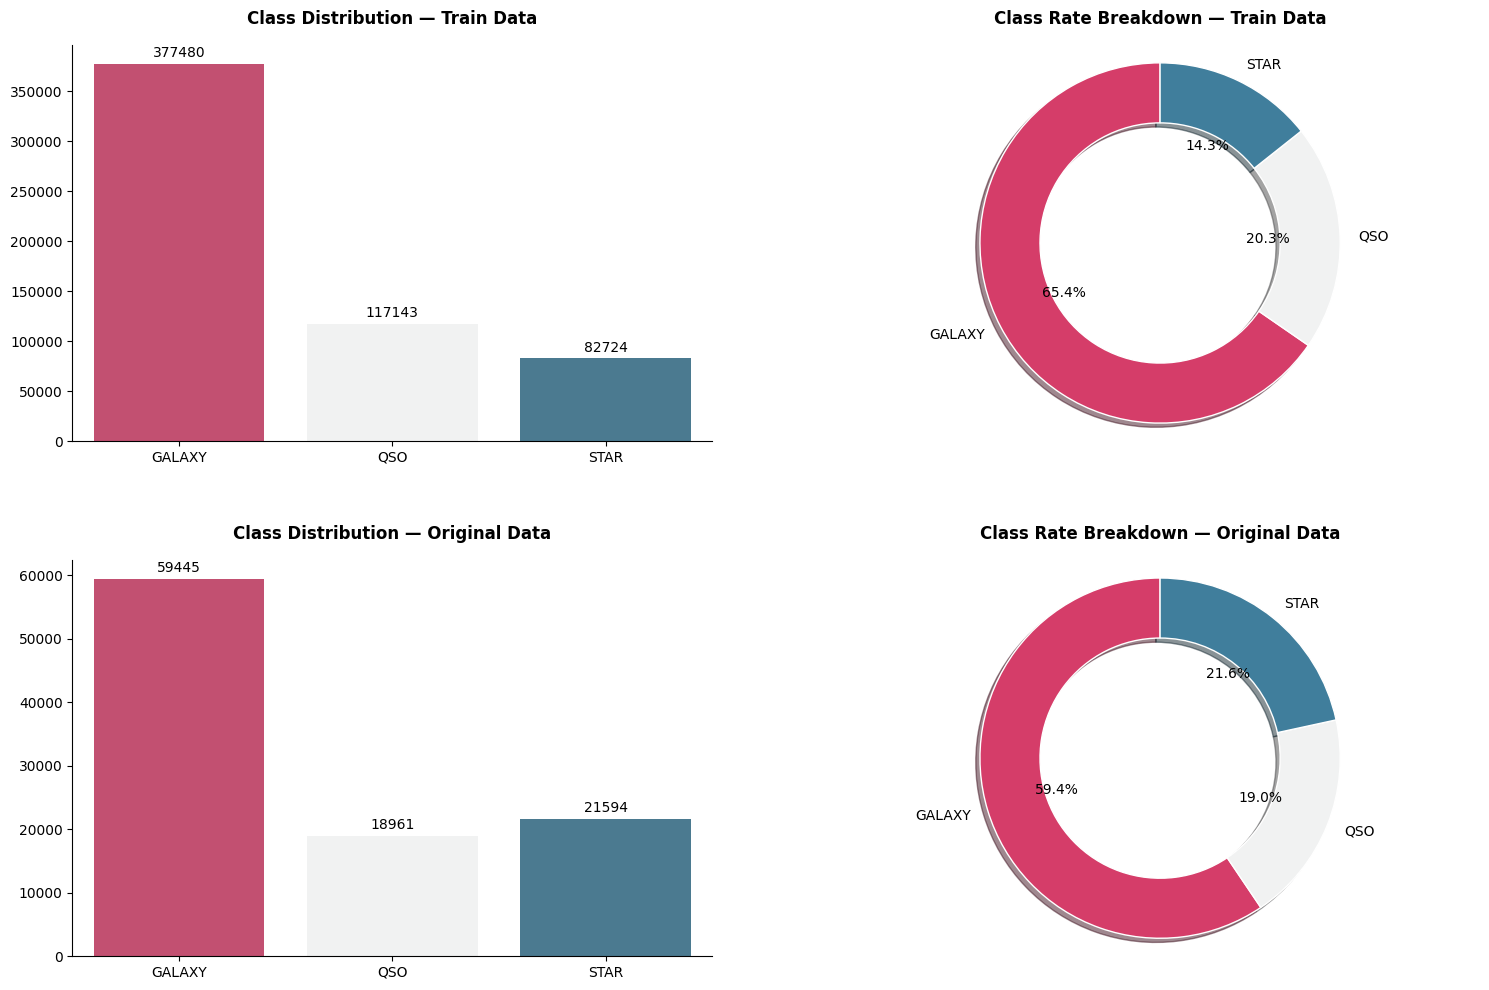

In [37]:
# Set target variable
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
datasets = [("Train Data", df_train), ("Original Data", df_original)]
n_color = df_train[CFG.TARGET_FEATURE].nunique()
order_irrigation_need = df_train[CFG.TARGET_FEATURE].unique().tolist()

for i, (title, data) in enumerate(datasets):
    ax = axes[i, 0]

    # Vertical barplot
    sns.countplot(x=CFG.TARGET_FEATURE, data=data, ax=ax,
                  palette=color(n_colors=n_color), order=order_irrigation_need)
    ax.set_title(f"Class Distribution — {title}", pad=15, weight="bold", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

    # Add count labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        x = p.get_x() + p.get_width() / 2
        ax.text(x, height + max(data[CFG.TARGET_FEATURE].value_counts()) * 0.01,
                f"{int(height)}",
                ha="center", va="bottom", fontsize=10, color="black")

    # Pie chart
    y_counts = data[CFG.TARGET_FEATURE].value_counts().reindex(order_irrigation_need)
    wedges, texts, autotexts = axes[i, 1].pie(
        y_counts, autopct="%1.1f%%", startangle=90, colors=color(n_colors=n_color), wedgeprops=dict(width=0.4, edgecolor="w"),
        radius=1.2,  shadow=True, labels=order_irrigation_need)
    for text in texts + autotexts:
        text.set_fontsize(10)

    centre_circle = plt.Circle((0, 0), 0.70, fc="white")
    axes[i, 1].add_artist(centre_circle)
    axes[i, 1].set_title(f"Class Rate Breakdown — {title}", pad=15, weight="bold", fontsize=12)
    axes[i, 1].axis("equal")

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()